In [1]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import datasets
from itertools import cycle, islice
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="ticks")
np.random.seed(100)
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
cluster_n_samples = 2500

datasets_names = ['circles', 'moons', 'blobs', 'aniso', 'varied', 'no_structure']


def generate_datasets(n_samples):
    """
    Генерация набора данных на 1500 точек
    """
    noisy_circles, noisy_circles_y = datasets.make_circles(
        n_samples=n_samples, factor=.5, noise=.05)
    noisy_moons, noisy_moons_y = datasets.make_moons(n_samples=n_samples, noise=.05)
    blobs, blobs_y = datasets.make_blobs(n_samples=n_samples, random_state=8)
    no_structure = np.random.rand(n_samples, 2)

    X_aniso, y_aniso = datasets.make_blobs(n_samples=n_samples, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    aniso = np.dot(X_aniso, transformation)

    varied, varied_y = datasets.make_blobs(
        n_samples=n_samples,
        cluster_std=[1.0, 2.5, 0.5],
        random_state=170)

    result_y = [noisy_circles_y, noisy_moons_y, varied_y, y_aniso, blobs_y]

    result_not_scaled = [noisy_circles, noisy_moons,
                         varied, aniso, blobs, no_structure]

    # Нормализуем признаки
    result = []
    for data in result_not_scaled:
        data_res = StandardScaler().fit_transform(data)
        result.append(data_res)

    return result, result_y

In [3]:
cluster_datasets, cluster_true_y = generate_datasets(cluster_n_samples)

In [4]:
len(cluster_datasets)

6

In [5]:
cluster_datasets[0].shape

(2500, 2)

In [6]:
cluster_datasets[0]

array([[ 1.70913446, -0.06676798],
       [-1.54183817,  1.0925355 ],
       [ 1.6678468 , -0.80705576],
       ...,
       [ 1.64220053,  0.61395176],
       [-0.83456533,  0.08619155],
       [ 0.10085065,  0.90170451]])

In [7]:
len(cluster_true_y)

5

In [8]:
cluster_true_y[0].shape

(2500,)

In [9]:
cluster_true_y[0]

array([0, 0, 0, ..., 0, 1, 1])

In [10]:
for cluster in cluster_true_y:
    print(np.unique(cluster))

[0 1]
[0 1]
[0 1 2]
[0 1 2]
[0 1 2]


In [11]:

def visualize_clusters(cluster_datasets, cluster_results):
    """
    Визуализация результатов кластерного анализа
    """
    plt.subplots(figsize=(10,7))
    plot_num = 0
    for X, y_pred in zip(cluster_datasets, cluster_results):
        plot_num += 1
        plt.subplot(2, 3, plot_num)
        # Цвета точек как результат кластеризации
        colors = np.array(list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a',
                                             '#f781bf', '#a65628', '#984ea3',
                                             '#999999', '#e41a1c', '#dede00']),
                                      int(max(y_pred) + 1))))
        # черный цвет для выделяющихся значений
        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=3, color=colors[y_pred])
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.title(datasets_names[plot_num-1])

    plt.show()

In [12]:
cluster_results_empty = []
for i in range(6):
    cluster_results_empty.append(np.zeros(cluster_n_samples, dtype=int))

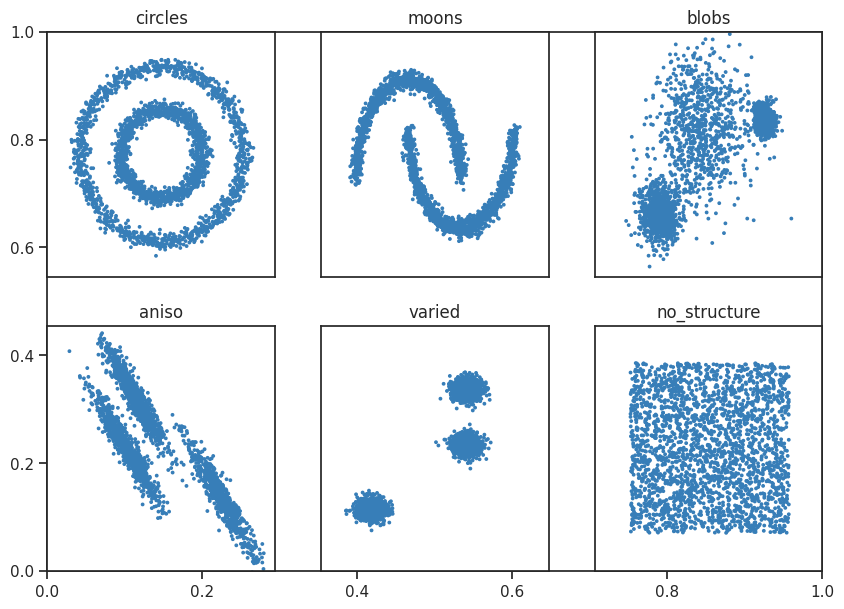

In [13]:
visualize_clusters(cluster_datasets, cluster_results_empty)

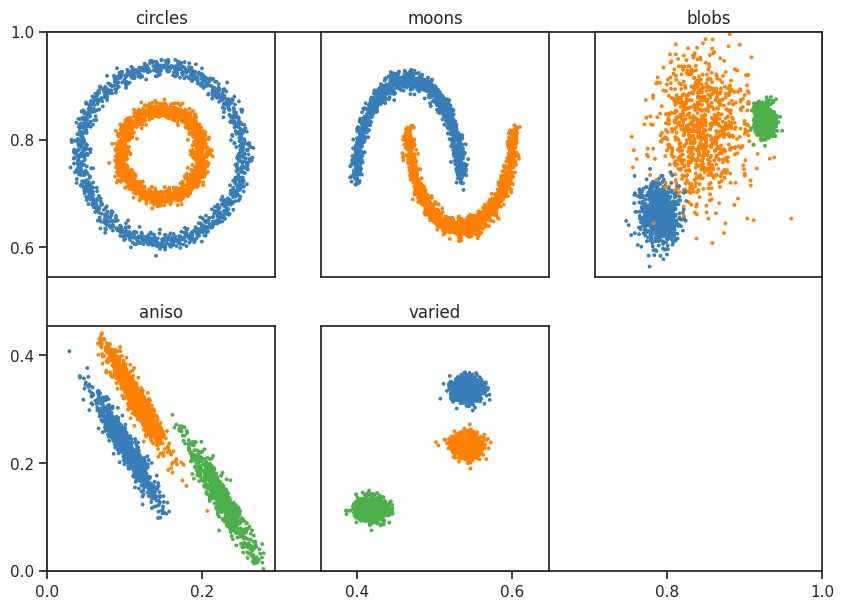

In [14]:
visualize_clusters(cluster_datasets, cluster_true_y)

In [15]:
def do_clustering(cluster_datasets, method):
    """
    Выполнение кластеризации для данных примера
    """
    cluster_results = []
    for X in cluster_datasets:
        temp_cluster = method.fit_predict(X)
        cluster_results.append(temp_cluster)
    return cluster_results

In [16]:
%time result_KMeans_3 = do_clustering(cluster_datasets, KMeans(n_clusters=3))

CPU times: user 52.8 ms, sys: 7.04 ms, total: 59.8 ms
Wall time: 125 ms


In [17]:
%time result_KMeans_5 = do_clustering(cluster_datasets, KMeans(n_clusters=5))

CPU times: user 43.2 ms, sys: 0 ns, total: 43.2 ms
Wall time: 46.8 ms


In [18]:
%time result_KMeans_plus_3 = do_clustering(cluster_datasets, KMeans(n_clusters=3, init='k-means++'))

CPU times: user 29.6 ms, sys: 0 ns, total: 29.6 ms
Wall time: 34.6 ms


In [19]:
%time result_KMeans_batch_3 = do_clustering(cluster_datasets, MiniBatchKMeans(n_clusters=3))

CPU times: user 61.3 ms, sys: 0 ns, total: 61.3 ms
Wall time: 86 ms


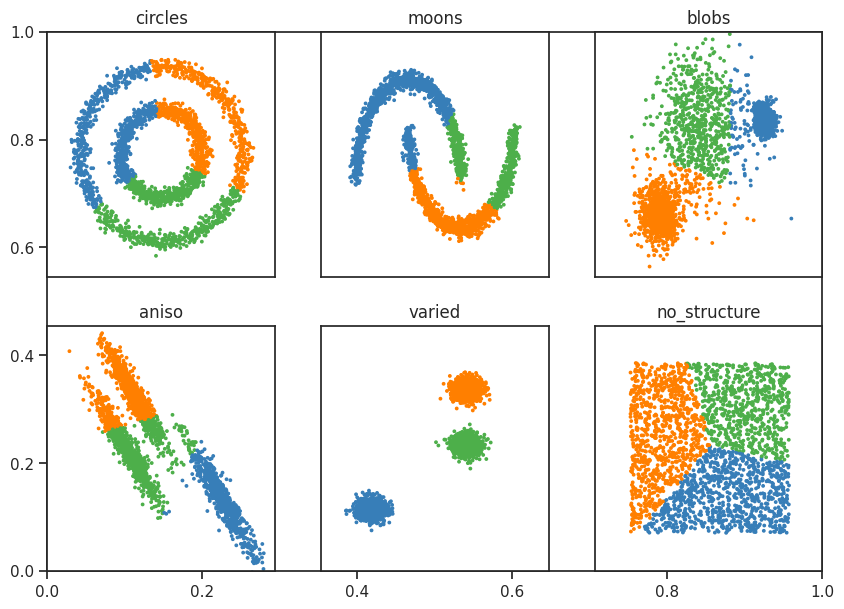

In [20]:
visualize_clusters(cluster_datasets, result_KMeans_3)

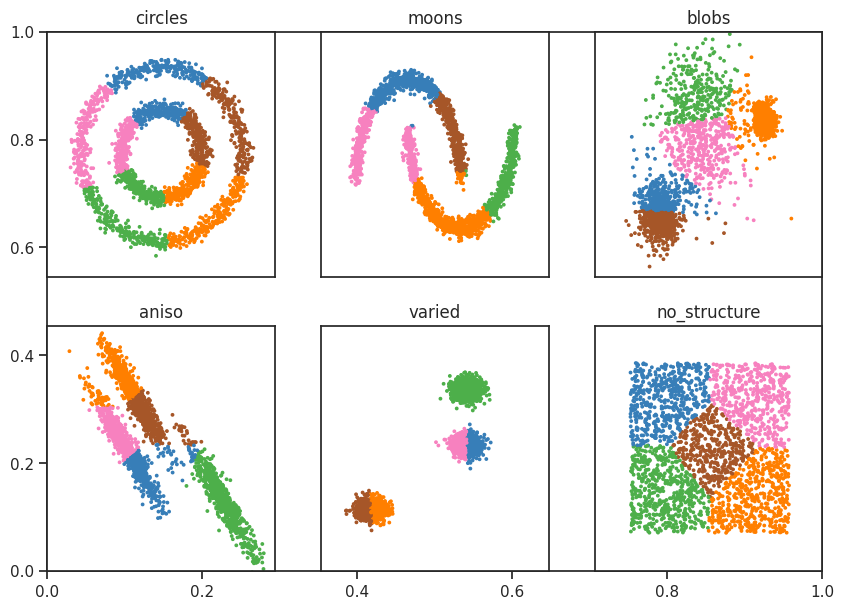

In [21]:

visualize_clusters(cluster_datasets, result_KMeans_5)

In [22]:
with warnings.catch_warnings(record=True):
    np.random.seed(0)
    mean = np.array([0.0, 0.0])
    cov = np.array([[1.0, -1.0],
                    [-2.0, 3.0]])
    X1 = np.random.multivariate_normal(mean, cov, 300)
X1[:10]

array([[-1.83120164,  2.95185814],
       [-0.17650378,  2.22936562],
       [-2.52117612,  2.71453894],
       [-1.13880803,  1.48231246],
       [ 0.28761926, -0.04553854],
       [ 0.44160322,  0.65761433],
       [-0.81119653,  1.25854161],
       [-0.36387766,  0.81100797],
       [-1.77718918,  2.34066738],
       [-0.70966524,  0.25277676]])

In [23]:

pca = PCA()
pca.fit(X1)
print('Доля объясненной дисперсии: {}'.format(pca.explained_variance_ratio_))

Доля объясненной дисперсии: [0.93905057 0.06094943]


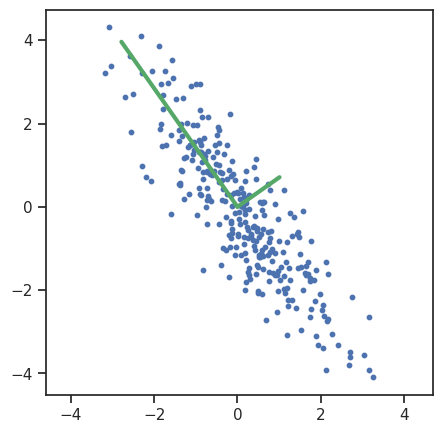

In [24]:
plt.figure(figsize=(5,5))
plt.scatter(X1[:, 0], X1[:, 1], s=10, c='b')
for l, v in zip(pca.explained_variance_ratio_, pca.components_):
    d = 5 * np.sqrt(l) * v
    plt.plot([0, d[0]], [0, d[1]], '-g', lw=3)
plt.axis('equal')
plt.show()

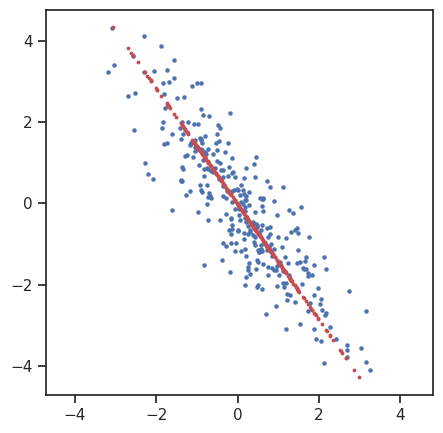

In [25]:
pca = PCA(0.85)
X_reduced = pca.fit_transform(X1)

# Строим проекции на главную компоненту
X_new = pca.inverse_transform(X_reduced)

plt.figure(figsize=(5,5))
plt.scatter(X1[:, 0], X1[:, 1], s=5, c='b')
plt.scatter(X_new[:, 0], X_new[:, 1], s=3, c='r')
plt.axis('equal')
plt.show()

In [26]:
wine = datasets.load_wine()
wine_X, wine_y = wine.data, wine.target
wine_X[:10]

array([[1.423e+01, 1.710e+00, 2.430e+00, 1.560e+01, 1.270e+02, 2.800e+00,
        3.060e+00, 2.800e-01, 2.290e+00, 5.640e+00, 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, 1.120e+01, 1.000e+02, 2.650e+00,
        2.760e+00, 2.600e-01, 1.280e+00, 4.380e+00, 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, 1.860e+01, 1.010e+02, 2.800e+00,
        3.240e+00, 3.000e-01, 2.810e+00, 5.680e+00, 1.030e+00, 3.170e+00,
        1.185e+03],
       [1.437e+01, 1.950e+00, 2.500e+00, 1.680e+01, 1.130e+02, 3.850e+00,
        3.490e+00, 2.400e-01, 2.180e+00, 7.800e+00, 8.600e-01, 3.450e+00,
        1.480e+03],
       [1.324e+01, 2.590e+00, 2.870e+00, 2.100e+01, 1.180e+02, 2.800e+00,
        2.690e+00, 3.900e-01, 1.820e+00, 4.320e+00, 1.040e+00, 2.930e+00,
        7.350e+02],
       [1.420e+01, 1.760e+00, 2.450e+00, 1.520e+01, 1.120e+02, 3.270e+00,
        3.390e+00, 3.400e-01, 1.970e+00, 6.750e+00, 1.050e+00, 2.850e+00,
        1.45

In [27]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(wine_X)
print('Доля объясненной дисперсии: {}, сумма={}'.format(pca.explained_variance_ratio_, np.sum(pca.explained_variance_ratio_)))
X_reduced[:10]

Доля объясненной дисперсии: [0.99809123 0.00173592], сумма=0.9998271461166032


array([[ 3.18562979e+02,  2.14921307e+01],
       [ 3.03097420e+02, -5.36471768e+00],
       [ 4.38061133e+02, -6.53730945e+00],
       [ 7.33240139e+02,  1.92729032e-01],
       [-1.15714285e+01,  1.84899946e+01],
       [ 7.03231192e+02, -3.32158674e-01],
       [ 5.42971581e+02, -1.35189666e+01],
       [ 5.48401860e+02,  1.14494324e+01],
       [ 2.98036863e+02, -8.18015784e+00],
       [ 2.98049553e+02, -7.10154294e+00]])

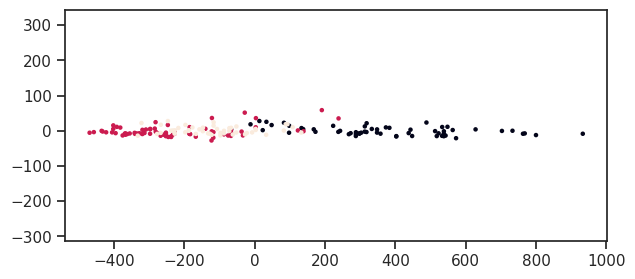

In [28]:
plt.figure(figsize=(7,3))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=5, c=wine_y)
plt.axis('equal')
plt.show()

In [29]:
tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(wine_X)
X_embedded[:10]

array([[11.885133  , -0.4805385 ],
       [11.506394  , -1.1478491 ],
       [14.050035  , -1.0155274 ],
       [16.86393   , -1.3842843 ],
       [ 3.2683203 , -0.4515415 ],
       [16.71953   , -1.0672652 ],
       [15.556519  , -0.82021946],
       [15.5799885 , -1.4696133 ],
       [11.37821   , -1.1492682 ],
       [11.423555  , -0.5429346 ]], dtype=float32)

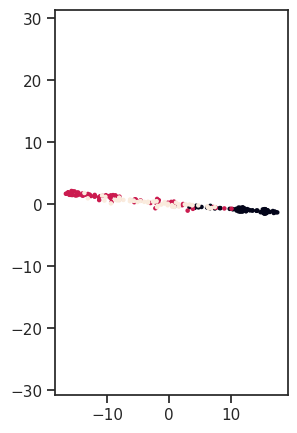

In [30]:

plt.figure(figsize=(3,5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=5, c=wine_y)
plt.axis('equal')
plt.show()